## 1) Libraries

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import RidgeCV, LassoCV, LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score, cross_val_predict, cross_validate, GridSearchCV, KFold, RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, BaggingRegressor, BaggingClassifier, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

In [37]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [38]:
# to check for missing values
print("Missing values in TRAIN:")
print(train.isnull().sum().sort_values(ascending=False))

print("\nMissing values in TEST:")
missing_test = test.isnull().sum()
print(test.isnull().sum().sort_values(ascending=False))

Missing values in TRAIN:
host_about                                      3010
host_location                                   2009
reviews_per_month                               1810
last_review                                     1810
review_scores_accuracy                          1810
review_scores_cleanliness                       1810
review_scores_checkin                           1810
review_scores_communication                     1810
review_scores_location                          1810
review_scores_value                             1810
first_review                                    1810
review_scores_rating                            1810
host_neighbourhood                              1514
host_response_time                               557
host_response_rate                               557
host_acceptance_rate                             331
description                                      260
has_availability                                  41
bedrooms             

In [39]:
# drop useless text columns
drop_cols = ['description', 'host_about', 'host_location', 'host_neighbourhood', 'amenities','first_review', 'last_review', 'host_verifications', 'first_review', 'last_review', 'host_since', 'host_response_time']
train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

# convert to pure numbers
def convert_percent(x):
    return x.str.rstrip('%').astype(float)

for col in ['host_response_rate', 'host_acceptance_rate']:
    train[col] = convert_percent(train[col])
    test[col] = convert_percent(test[col])

def extract_bathrooms(x):
    return x.str.extract('(\d*\.?\d+)').astype(float)

train['bathrooms'] = extract_bathrooms(train['bathrooms_text'])
test['bathrooms'] = extract_bathrooms(test['bathrooms_text'])
train = train.drop(columns=['bathrooms_text'])
test = test.drop(columns=['bathrooms_text'])

bool_cols = ['host_has_profile_pic', 'host_identity_verified', 'has_availability', 'instant_bookable']
for col in bool_cols:
    train[col] = train[col].astype(float)
    test[col] = test[col].astype(float)

In [40]:
# impute
num_impute_cols = ['bedrooms', 'beds', 'bathrooms']
for col in num_impute_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(train[col].median())

review_cols = [col for col in train.columns if 'review_scores' in col] + ['reviews_per_month']
for col in review_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(train[col].median())

rate_cols = ['host_response_rate', 'host_acceptance_rate']
for col in rate_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(train[col].median())

cat_cols = ['host_has_profile_pic', 'host_identity_verified',
            'has_availability', 'instant_bookable']
for col in cat_cols:
    mode = train[col].mode()[0]
    train[col] = train[col].fillna(mode)
    test[col] = test[col].fillna(mode)

listings_cols = ['host_listings_count', 'host_total_listings_count']
for col in listings_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(train[col].median())

train['price'] = train['price'].replace('[\$,]', '', regex=True).astype(float)
y_train = train['price']
y_train_log = np.log(train['price'])

X_train = train.drop(columns=['id', 'price'])
X_test = test.drop(columns=['id'])

In [41]:
# check missing again
print("Missing values in TRAIN:")
print(train.isnull().sum().sort_values(ascending=False).head(5))

print("\nMissing values in TEST:")
print(test.isnull().sum().sort_values(ascending=False).head(5))

Missing values in TRAIN:
id                           0
review_scores_cleanliness    0
availability_30              0
availability_60              0
availability_90              0
dtype: int64

Missing values in TEST:
id                           0
review_scores_cleanliness    0
availability_30              0
availability_60              0
availability_90              0
dtype: int64


In [42]:
# OHE
X_train = pd.get_dummies(X_train, columns=['listing_location', 'room_type', 'property_type', 'neighbourhood_cleansed'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['listing_location', 'room_type', 'property_type', 'neighbourhood_cleansed'], drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [84]:
X_train['bed_bath_ratio'] = X_train['bedrooms'] / (X_train['bathrooms'] + 1)

X_test['bed_bath_ratio'] = X_test['bedrooms'] / (X_test['bathrooms'] + 1)

In [43]:
# scaling
#scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

In [44]:
#poly = PolynomialFeatures(degree=2, include_bias=False)
#X_train_poly = poly.fit_transform(X_train)
#X_test_poly = poly.transform(X_test)

In [45]:
#kf = KFold(n_splits=5, shuffle=True, random_state=12)

#y_train = np.exp(y_train_log)

In [46]:
#ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=kf)
#ridge_preds_log = cross_val_predict(ridge, X_train_scaled, y_train_log, cv=kf)
#ridge_mae = mean_absolute_error(y_train, np.exp(ridge_preds_log))
#print(f"Ridge MAE: {ridge_mae:.2f}")

In [47]:
#lasso = LassoCV(alphas=np.logspace(-3, 3, 50), cv=kf, max_iter=10000)
#lasso_preds_log = cross_val_predict(lasso, X_train_scaled, y_train_log, cv=kf)
#lasso_mae = mean_absolute_error(y_train, np.exp(lasso_preds_log))
#print(f"Lasso MAE: {lasso_mae:.2f}")

In [48]:
#best_knn_mae = float('inf')
#best_k = 5
#for k in [5, 10, 15, 20]:
#    knn = KNeighborsRegressor(n_neighbors=k)
#    knn_preds_log = cross_val_predict(knn, X_train_scaled, y_train_log, cv=kf)
#    current_mae = mean_absolute_error(y_train, np.exp(knn_preds_log))
#    if current_mae < best_knn_mae:
#        best_knn_mae = current_mae
#        best_k = k
#print(f"Best KNN (k={best_k}) MAE: {best_knn_mae:.2f}")

In [49]:
#param_grid = {
#    'n_neighbors': range(5, 35, 3),
#    'weights': ['uniform', 'distance'],
#    'p': [1, 2]  # 1: Manhattan, 2: Euclidean
#}

#knn = KNeighborsRegressor()
#kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search with MAE scoring
#grid_search = GridSearchCV(knn, param_grid, 
#                          scoring='neg_mean_absolute_error',
#                          cv=kf,
#                          n_jobs=-1)

#grid_search.fit(X_train_scaled, y_train_log)

# Best model from grid search
#best_knn = grid_search.best_estimator_
#print(f"Best parameters: {grid_search.best_params_}")
#print(f"Best CV MAE: {-grid_search.best_score_:.2f}")

In [50]:
# bagging 
base_model = DecisionTreeRegressor(random_state=12)

model = BaggingRegressor(
    random_state=12,
    estimator=base_model,
    n_estimators=50,
    oob_score=True
)

model.fit(X_train, y_train)

BaggingRegressor(estimator=DecisionTreeRegressor(random_state=12),
                 n_estimators=50, oob_score=True, random_state=12)

Text(0, 0.5, 'OOB MAE')

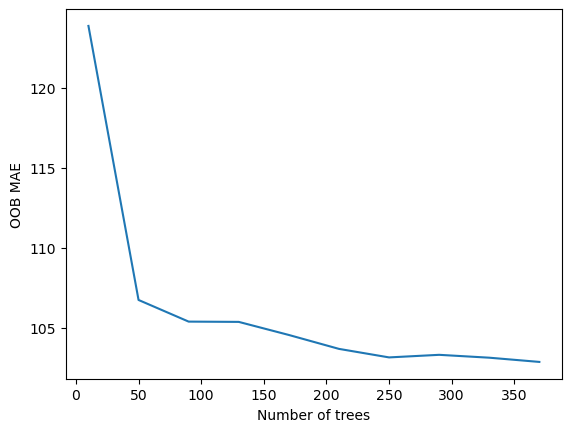

In [52]:
# find a good n_estimators, where the OOB score does not change anymore

oob_mae = []

num_trees = np.arange(10,400,40) # we will try these values as n_estimators

for num_tree in num_trees:
    base_model = DecisionTreeRegressor(random_state=12)
    model = BaggingRegressor(
        random_state= 12,
        estimator= base_model,
        n_estimators= num_tree,
        oob_score= True 
    )
    model.fit(X_train, y_train)
    oob_mae.append(mean_absolute_error(y_train, model.oob_prediction_))

plt.plot(num_trees, oob_mae)
plt.xlabel('Number of trees')
plt.ylabel('OOB MAE')

In [54]:
base_model = DecisionTreeRegressor(random_state=12)

model = BaggingRegressor(
    random_state= 12,
    estimator= base_model,
    n_estimators= 250,
    oob_score= True 
)

grid = {
    'max_samples':  [0.5, 0.75, 1.0], 
    'max_features': [0.5, 0.75, 1.0], 
    'bootstrap': [True, False],
    'bootstrap_features': [True, False]
}

cv = KFold(n_splits=5, shuffle=True, random_state=1)

gcsv = GridSearchCV(model, grid, cv=cv, scoring='neg_mean_absolute_error', verbose=1, n_jobs=-1)

gcsv.fit(X_train, y_train)

print("best params:", gcsv.best_params_)
print("CV MAE:", -gcsv.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
best params: {'bootstrap': True, 'bootstrap_features': True, 'max_features': 1.0, 'max_samples': 1.0}
CV MAE: 102.46363276272284


In [90]:
# random forest

model = RandomForestRegressor(
    random_state=12,
    n_estimators=250
)

grid = {
    'max_samples': [0.9, 1.0], 
    'max_features': [0.9, 1.0], 
    'max_depth': [None, 15, 25],
    'bootstrap': [True],
}

cv = KFold(n_splits=5, shuffle=True, random_state=1)

gcsv_rf = GridSearchCV(model, grid, cv=cv, scoring='neg_mean_absolute_error', verbose=1, n_jobs=-1)

gcsv_rf.fit(X_train, y_train)

print("best params:", gcsv.best_params_)
print("CV MAE:", -gcsv.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


python(78832) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(78833) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(78834) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(78835) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(78836) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(78837) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(78838) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(78839) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


KeyboardInterrupt: 

In [73]:
# Revised Random Forest with regularization
tuned_model = RandomForestRegressor(
    random_state=12,
    n_estimators=500,  # Increased for stability
    max_features=0.7,  # Reduced from 1.0 to improve generalization
    max_depth=15,      # Limit tree depth
    min_samples_leaf=5,# Prevent tiny leaves
    bootstrap=True,
    n_jobs=-1,
    oob_score=True     # Enable OOB estimates
)

tuned_model.fit(X_train, y_train)

# Check OOB MAE
oob_pred = tuned_model.oob_prediction_
oob_mae = mean_absolute_error(y_train, oob_pred)
print(f"OOB MAE: ${oob_mae:.2f}")  # Compare with Kaggle score

OOB MAE: $101.74


In [93]:
# xgb

# Simplified parameter grid
param_grid = {
    'learning_rate': [0.03, 0.05, 0.07, 0.1],
    'max_depth': np.arange(5, 12),          
    'subsample': np.arange(0.7, 1.01, 0.1),       
    'colsample_bytree': np.arange(0.5, 1.01, 0.1),
    'reg_lambda': [0, 0.1, 0.5, 1, 2, 5],
    'gamma': [0, 0.01, 0.05, 0.1, 0.2]
}

# Base model
xgb_model = XGBRegressor(
    random_state=12,
    n_estimators=1000,
    n_jobs=-1
)

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=12)

# Grid search
grid_search = RandomizedSearchCV(
    xgb_model,
    param_grid,
    cv=cv,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train_log)

# Best model
print(f"Best MAE: {-grid_search.best_score_:.2f}")
print("Best Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


python(79198) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(79199) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(79200) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(79201) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(79202) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(79203) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(79204) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(79205) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Best MAE: 0.24
Best Parameters: {'subsample': 0.7, 'reg_lambda': 0.1, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.7999999999999999}


In [ ]:
xgb_model = XGBRegressor(
    random_state=12,
    n_estimators=400,
    learning_rate=0.05,
    max_depth=9,
    subsample=0.89,
    colsample_bytree=0.5,
    reg_lambda=1,
    gamma=0.1,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train,)

test_pred = xgb_model.predict(X_test)
# 104.83

In [ ]:
xgb_model = XGBRegressor(
    random_state=12,
    n_estimators=400,
    learning_rate=0.07,
    max_depth=7,
    subsample=0.89,
    colsample_bytree=0.6,
    reg_lambda=0,
    gamma=0.01,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train_log,)

test_pred = np.exp(xgb_model.predict(X_test))
# 97.01

In [ ]:
xgb_model = XGBRegressor(
    random_state=12,
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.7,
    colsample_bytree=0.79,
    reg_lambda=0.1,
    gamma=0,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train_log,)

test_pred = np.exp(xgb_model.predict(X_test))
# 96.64